<a href="https://colab.research.google.com/github/NishanRegmi/Pytorch/blob/main/cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
#set seed
torch.manual_seed(123)

In [11]:
df = pd.read_csv("/content/sample_data/fashion-mnist_train.csv")

In [12]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
df.shape

(60000, 785)

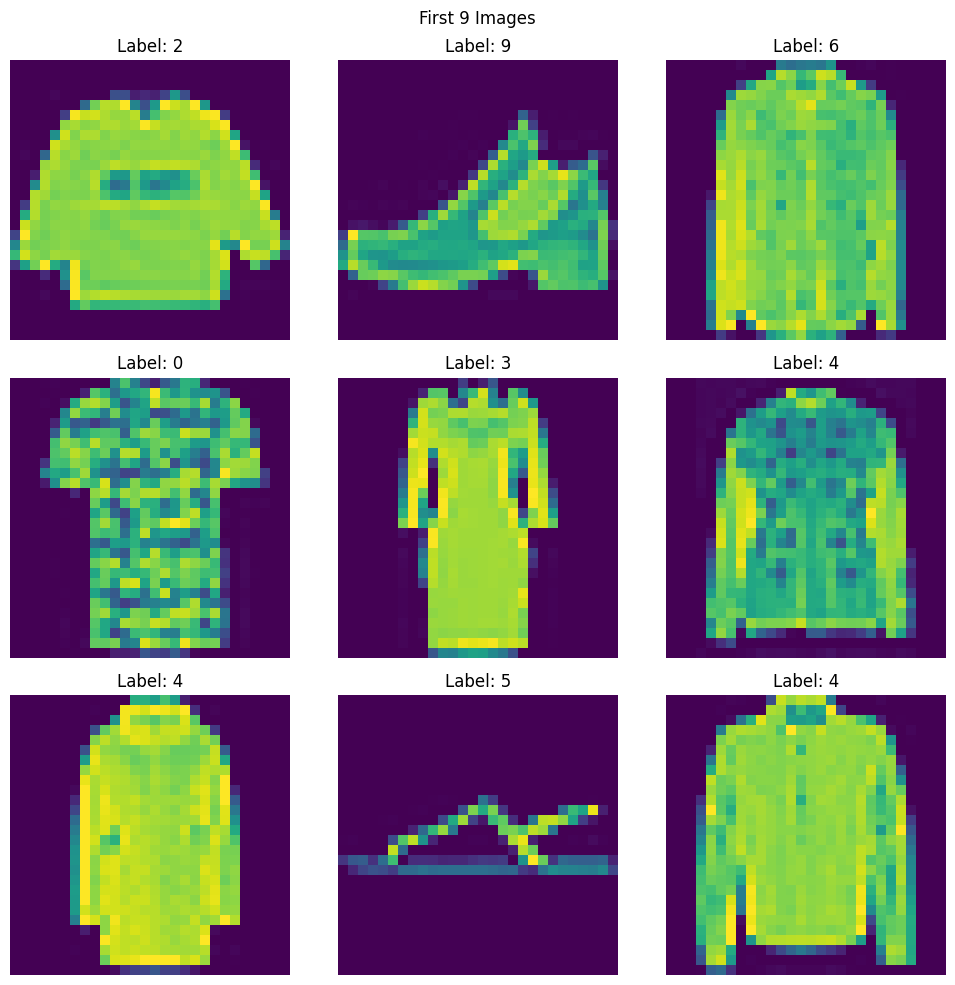

In [13]:
#first 9 images
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
plt.suptitle("First 9 Images")

for i, ax in enumerate(axes.flat):
  img = df.iloc[i, 1:].values.reshape(28, 28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f"Label: {df.iloc[i, 0]}")

plt.tight_layout()
plt.show()

In [14]:
#split
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=41)

In [16]:
X_train[1]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [16]:
#normalize
X_train = X_train/255.0
X_test = X_test/255.0

In [17]:
X_train[1]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [18]:
#dataset class
class Customdataset(Dataset):

  def __init__(self, features, labels):
    """
    CNN needs single image to process. In ANN we simply pick one row at a time but CNN need one complete image as input so
    we have to reshape it into (1, 28, 28). i.e. -1 = dynamic batch size, 1=single channel, 28 = height and 28 = width.
    how -1 works?
    If you have a flat array of 7,840 total numbers (pixels) and you reshape it using (-1, 1, 28, 28):
    The system multiplies the known dimensions: 1 × 28 × 28 = 784 pixels per image.
    It divides the total numbers by that result: 7,840 ÷ 784 = 10.
    The -1 automatically becomes 10, resulting in a final shape of (10, 1, 28, 28) (a batch of 10 images).
    """
    self.features = torch.tensor(features, dtype=torch.float32).reshape(-1, 1, 28, 28)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [19]:
trainset = Customdataset(X_train, y_train)
testset = Customdataset(X_test, y_test)

In [20]:
train_loader = DataLoader(trainset, batch_size=32, shuffle=True)
test_loader = DataLoader(testset, batch_size=32, shuffle=False)

In [21]:
#create nn model
"""
CNN works in two parts. i.e. feature extraction and classification. so we need to sequential container.
"""

class MyNeural(nn.Module):

  def __init__(self, input_features):
    super().__init__()

    self.features = nn.Sequential(
        nn.Conv2d(input_features, 32, kernel_size=3, padding='same'),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(32, 64, kernel_size=3, padding='same'),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64*7*7, 128),
        nn.ReLU(),
        nn.Dropout(p=0.4),

        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(p=0.4),

        nn.Linear(64, 10)
    )


  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

In [22]:
#hyperparameters
epochs = 100
learning_rate = 0.01

In [23]:
model = MyNeural(1)
model = model.to(device)

In [24]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [25]:
#training loop

for epoch in range(epochs):
  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    #forward pass
    output = model(batch_features)

    #loss
    loss = loss_function(output, batch_labels)

    #clear grad
    optimizer.zero_grad()

    #backward pass
    loss.backward()

    #update parameters
    optimizer.step()

    total_epoch_loss += loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f"Epoch: {epoch+1}, Loss: {avg_loss}")

Epoch: 1, Loss: 0.7850872663396602
Epoch: 2, Loss: 0.4869319049120857
Epoch: 3, Loss: 0.412598954001548
Epoch: 4, Loss: 0.37395277541621624
Epoch: 5, Loss: 0.34444631100472656
Epoch: 6, Loss: 0.32410114229020504
Epoch: 7, Loss: 0.3048672919492865
Epoch: 8, Loss: 0.2918748519803991
Epoch: 9, Loss: 0.28122725641044244
Epoch: 10, Loss: 0.2667559564073896
Epoch: 11, Loss: 0.2570346610709991
Epoch: 12, Loss: 0.24925945404993607
Epoch: 13, Loss: 0.23978018739969334
Epoch: 14, Loss: 0.22882685529583072
Epoch: 15, Loss: 0.22244675736945274
Epoch: 16, Loss: 0.2200480535816506
Epoch: 17, Loss: 0.20971907556244235
Epoch: 18, Loss: 0.20121694576798144
Epoch: 19, Loss: 0.19532678862969816
Epoch: 20, Loss: 0.19229840648893243
Epoch: 21, Loss: 0.18356721665460535
Epoch: 22, Loss: 0.17848263048444168
Epoch: 23, Loss: 0.1746710856712543
Epoch: 24, Loss: 0.16696236810880313
Epoch: 25, Loss: 0.16274711308378076
Epoch: 26, Loss: 0.16053252911119972
Epoch: 27, Loss: 0.15553959505526124
Epoch: 28, Loss: 0.1

In [26]:
model.eval()

MyNeural(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features

In [27]:
#test accuracy
total = 0
correct = 0
with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    output = model(batch_features)
    _, predicted = torch.max(output, 1)
    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()
print(correct/total)

0.9221666666666667


In [28]:
#train accuracy
total = 0
correct = 0
with torch.no_grad():
  for batch_features, batch_labels in train_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    output = model(batch_features)
    _, predicted = torch.max(output, 1)
    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()
print(correct/total)

0.9992857142857143
